# **19장. 의사 결정 트리 모델**

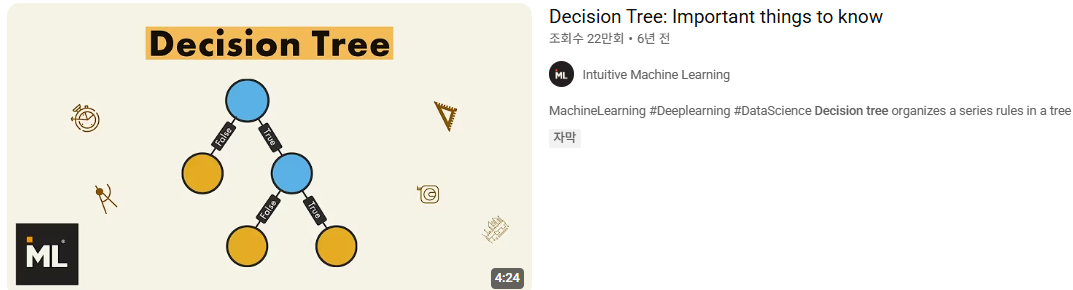

https://www.youtube.com/watch?v=JcI5E2Ng6r4

이 동영상은 결정트리 모델이 작동하는 방법을 쉽게 설명하고 있습니다.


---



[실습 19-01]

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df=pd.read_csv("자동차.csv", encoding="cp949")
print(df)

   car   price  power brand  sales
0    1   50000    200     A    752
1    2   50000    200     A    752
2    3   60000    500     A    752
3    4   70000    500     A    655
4    5   80000    700     A    607
5    6   90000    700     B    510
6    7  100000   1000     B    510
7    8  110000   1100     B    461
8    9  120000   1200     A    363
9   10  130000   1300     B    412


[실습 19-02]

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

# 피처와 타깃 지정
y=df["brand"]
X=df[["price", "power"]]

# 분류 트리 모델 생성 및 학습
분류_트리 = DecisionTreeClassifier(max_depth=2, random_state=42)
#분류_트리 = DecisionTreeClassifier(random_state=42)

분류_트리.fit(X, y)

# 예측 및 평가
y_pred = 분류_트리.predict(X)
print("예측된 클래스:", y_pred)
print("실제   클래스:", np.array(y))
accuracy = accuracy_score(y, y_pred)
print(f"예측 정확도: {accuracy:.2f}")

예측된 클래스: ['A' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'A']
실제   클래스: ['A' 'A' 'A' 'A' 'A' 'B' 'B' 'B' 'A' 'B']
예측 정확도: 0.90


[실습 19-03]

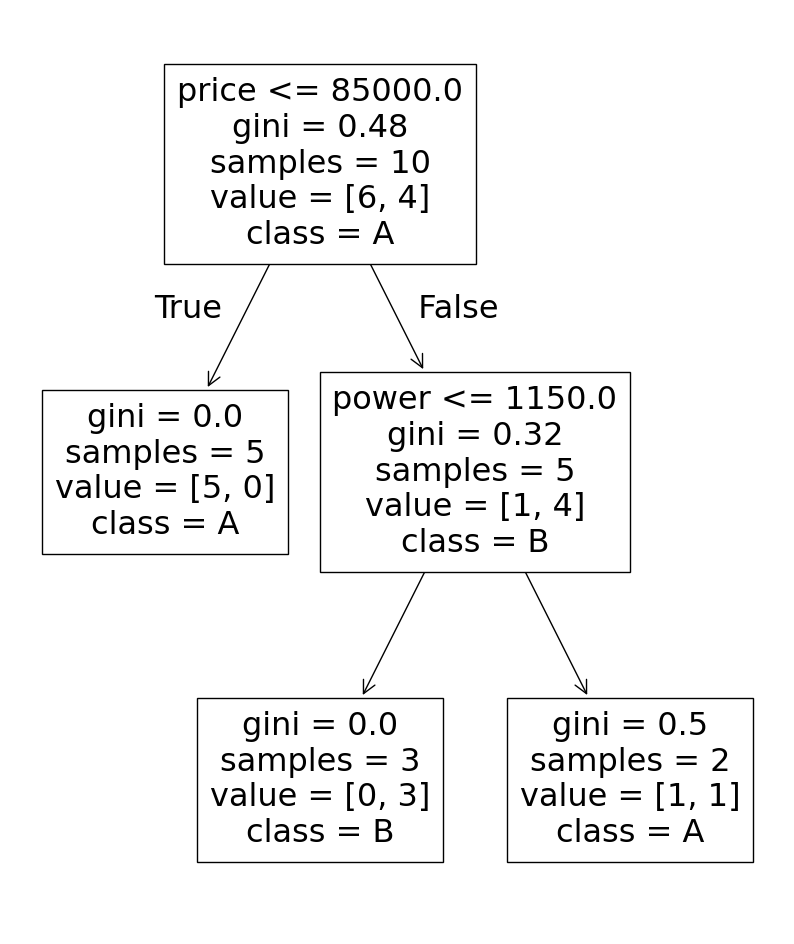

In [ ]:
plt.figure(figsize=(10, 12))
plot_tree(분류_트리, feature_names=X.columns, class_names=np.unique(y), filled=False)
plt.show()


[실습 19-04]

예측된 score: [752.  752.  752.  631.  631.  493.7 493.7 493.7 387.5 387.5]
실제   score: [752 752 752 655 607 510 510 461 363 412]
R²=  0.980


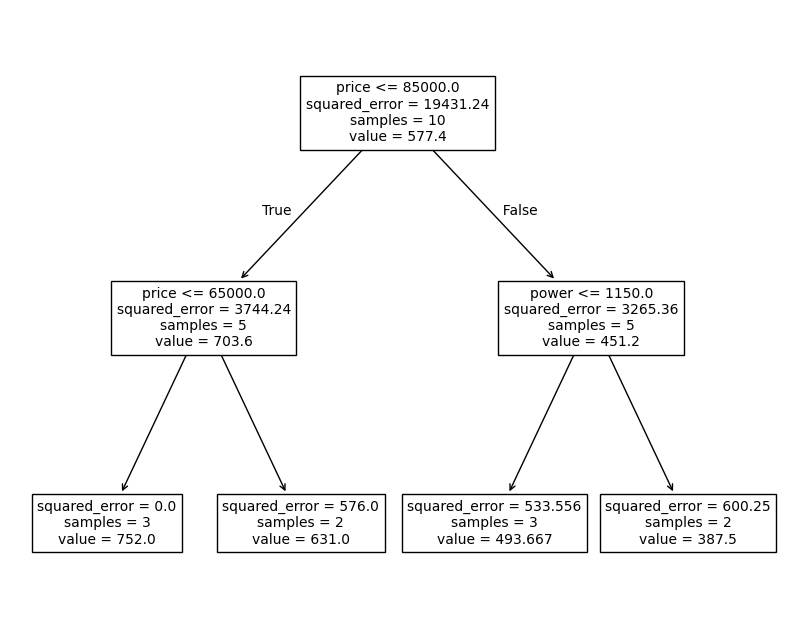

In [ ]:
# 라이브러리 추가
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 피처와 타깃 지정
y =df["sales"]
X=df[["price", "power"]]

# 회귀 트리 모델 생성 및 학습
회귀_트리 = DecisionTreeRegressor(max_depth=2, random_state=42)
#회귀_트리 = DecisionTreeRegressor(random_state=42)
회귀_트리.fit(X, y)

# 예측 및 평가
y_pred = 회귀_트리.predict(X)
print("예측된 score:", np.round(y_pred,1))
print("실제   score:", np.array(y))
r2 = r2_score(y, y_pred)
print(f"R\u00b2= {r2: .3f}")

# 학습한 회귀 트리 구조 시각화
plt.figure(figsize=(10, 8))
plot_tree(회귀_트리, feature_names=X.columns, filled=False)
plt.show()
